# 📘 Week 2 Assignment 

**Assignment Topic:** Build an end-to-end ML pipeline on sales/price data.

**Resources:** https://www.kaggle.com/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025

Importing the required Libraries

In [1]:
# Core data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings for cleaner output
import warnings

warnings.filterwarnings("ignore")

#### Section 1: Data Loading and Initial Exploration

Dateset Load and preview

In [2]:
# Load the Tesla deliveries dataset
df = pd.read_csv("Datasets/tesla_deliveries_dataset_2015_2025.csv")
print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")

# Display first few rows to understand structure
print("\nDataFrame based on dataset")
df.head()

Dataset loaded successfully!
Shape: (2640, 12)

DataFrame based on dataset


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


Information get from the data

In [3]:
# Get basic information about columns and data types
print("Information about the data\n")
df.info()

Information about the data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


Data Validation Check

In [4]:
# Check for missing values
print("Missing values per column:\n")
print(df.isnull().sum())

# Check for duplicate rows
print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")

Missing values per column:

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Number of duplicate rows: 0


Statistical Summary

In [5]:
# Summary statistics for numerical columns
print("Description Of Data")
df.describe()

Description Of Data


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


#### Section 2: Exploratory Data Analysis (EDA)

Univariate Analysis - Numerical Features

Graphical Understanding based on numerical features


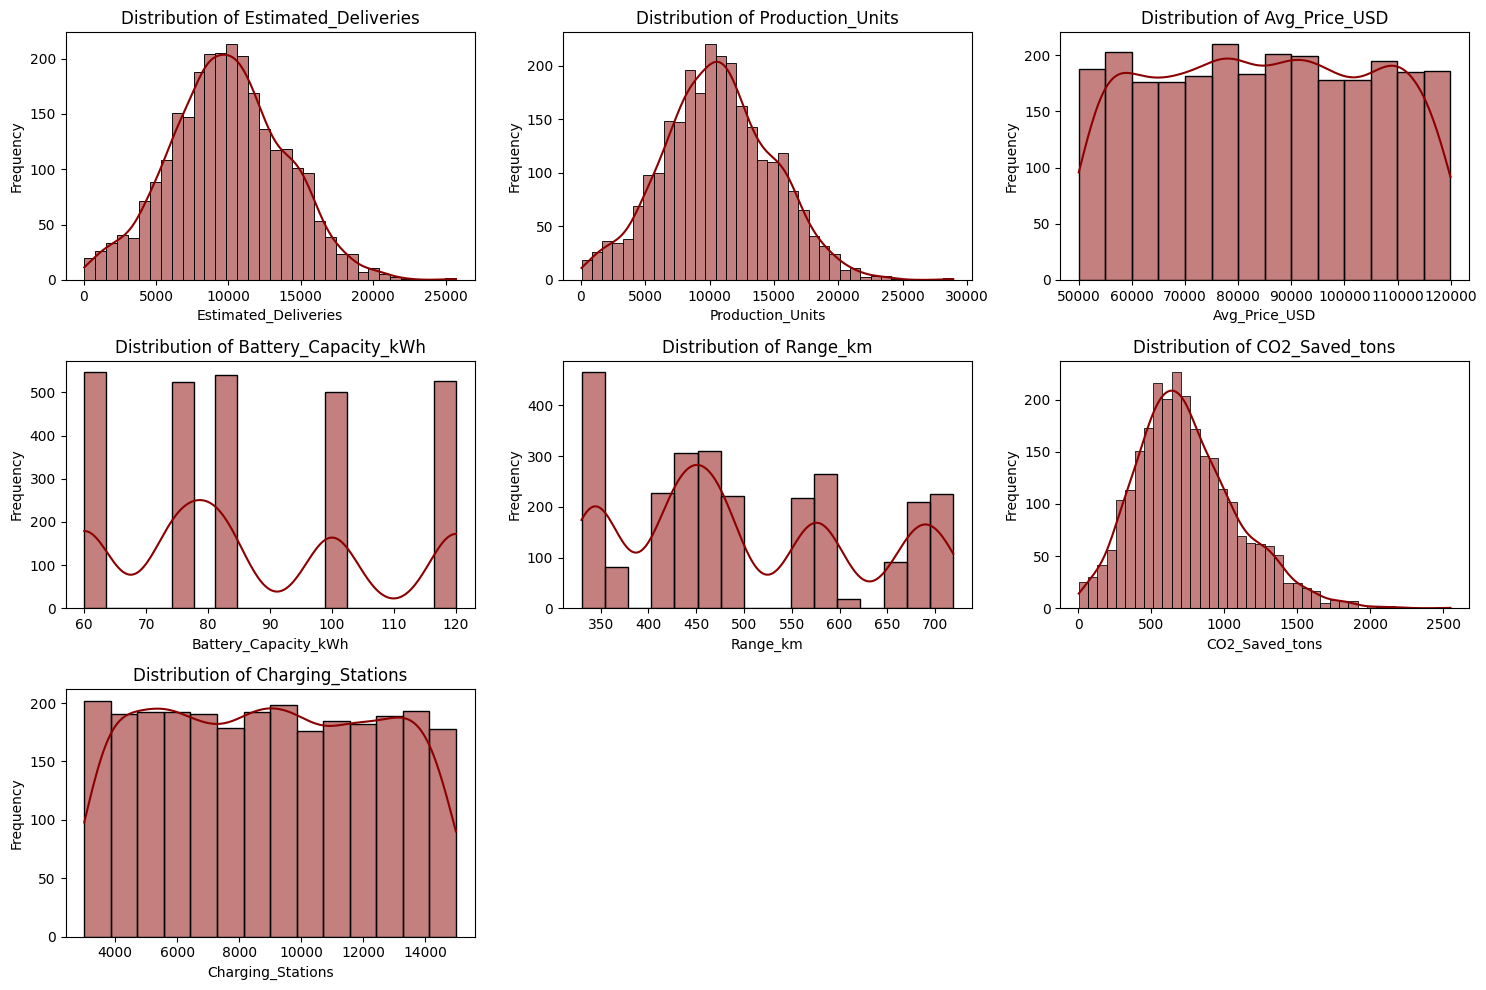

In [6]:
# Distribution plots for key numerical features
numerical_cols = [
    "Estimated_Deliveries",
    "Production_Units",
    "Avg_Price_USD",
    "Battery_Capacity_kWh",
    "Range_km",
    "CO2_Saved_tons",
    "Charging_Stations",
]

print("Graphical Understanding based on numerical features")

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True, color="darkred")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Univariate Analysis - Categorical Features

Graphical Understanding based on Categorical features


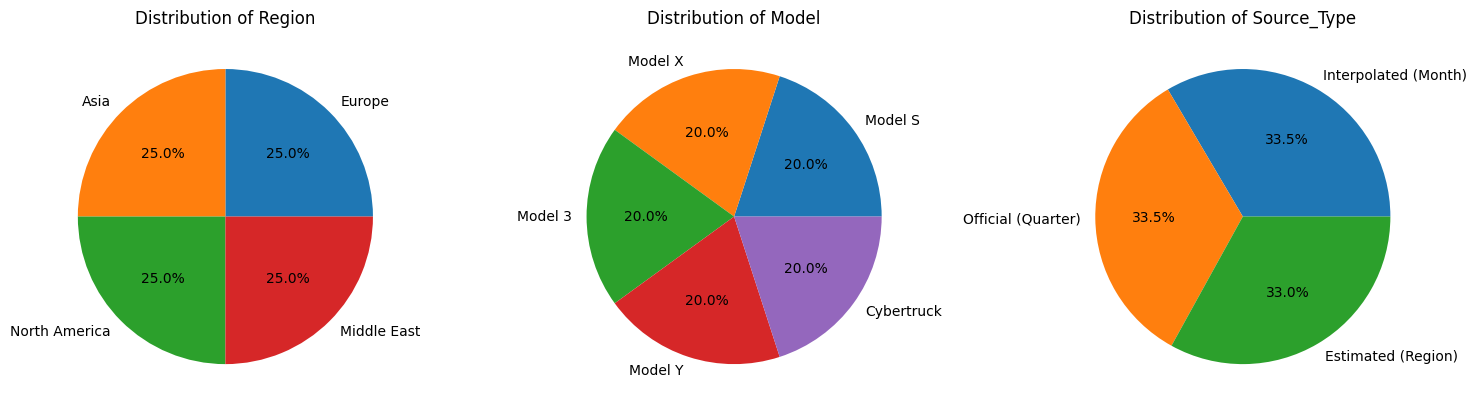

In [7]:
# Distribution of categorical variables
categorical_cols = ["Region", "Model", "Source_Type"]

print("Graphical Understanding based on Categorical features")

plt.figure(figsize=(15, 5))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(1, 3, i)
    value_counts = df[col].value_counts()
    plt.pie(value_counts.values, labels=value_counts.index, autopct="%1.1f%%")
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

Bivariate Analysis

Bivariate Analysis basedon Avg Price by Region


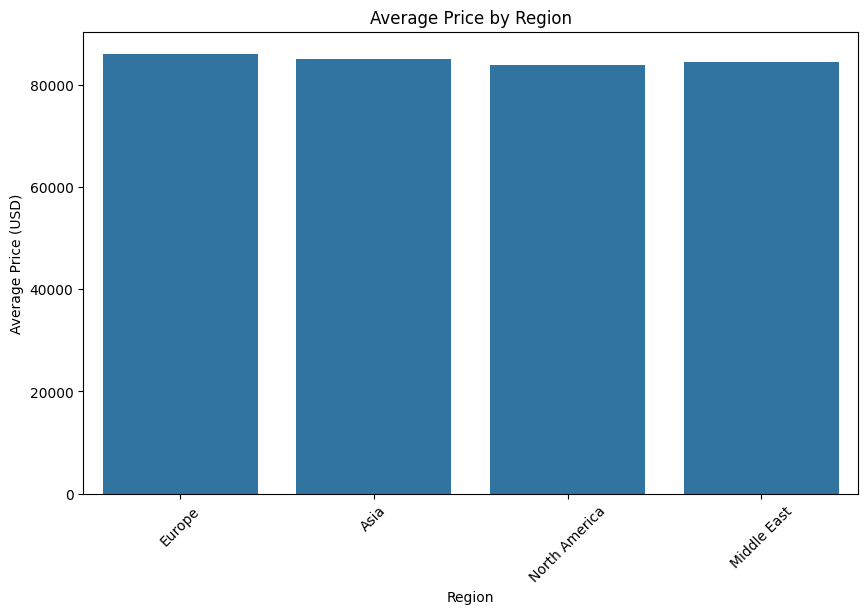

Bivariate Analysis basedon Avg Price by Model


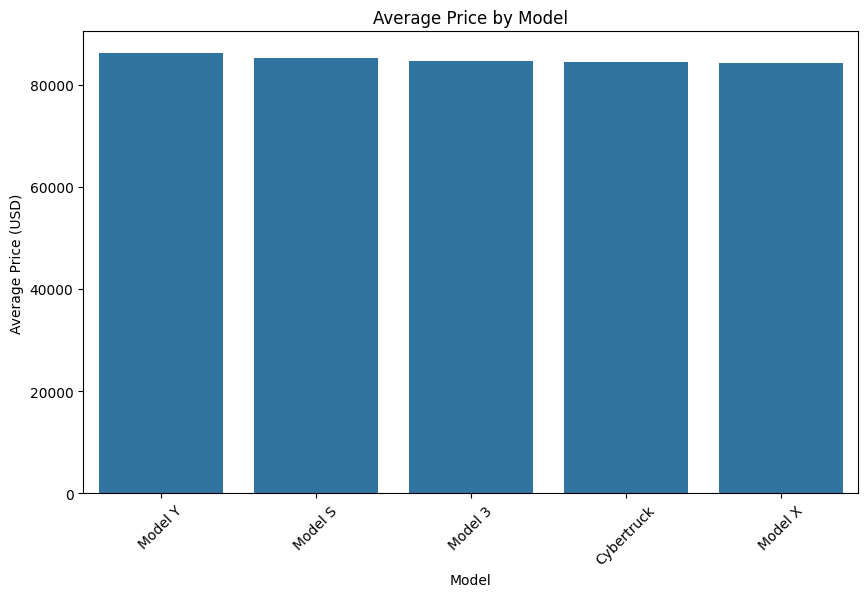

In [8]:
print("Bivariate Analysis basedon Avg Price by Region")

# Price variation across regions
plt.figure(figsize=(10, 6))
sns.barplot(x="Region", y="Avg_Price_USD", data=df, ci=False)
plt.title("Average Price by Region")
plt.xlabel("Region")
plt.ylabel("Average Price (USD)")
plt.xticks(rotation=45)
plt.show()

print("Bivariate Analysis basedon Avg Price by Model")

# Price variation across models
model_prices = df.groupby("Model")["Avg_Price_USD"].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=model_prices.index, y=model_prices.values)
plt.title("Average Price by Model")
plt.xlabel("Model")
plt.ylabel("Average Price (USD)")
plt.xticks(rotation=45)
plt.show()

Correlation Analysis

Calculating the Correlation Matrix


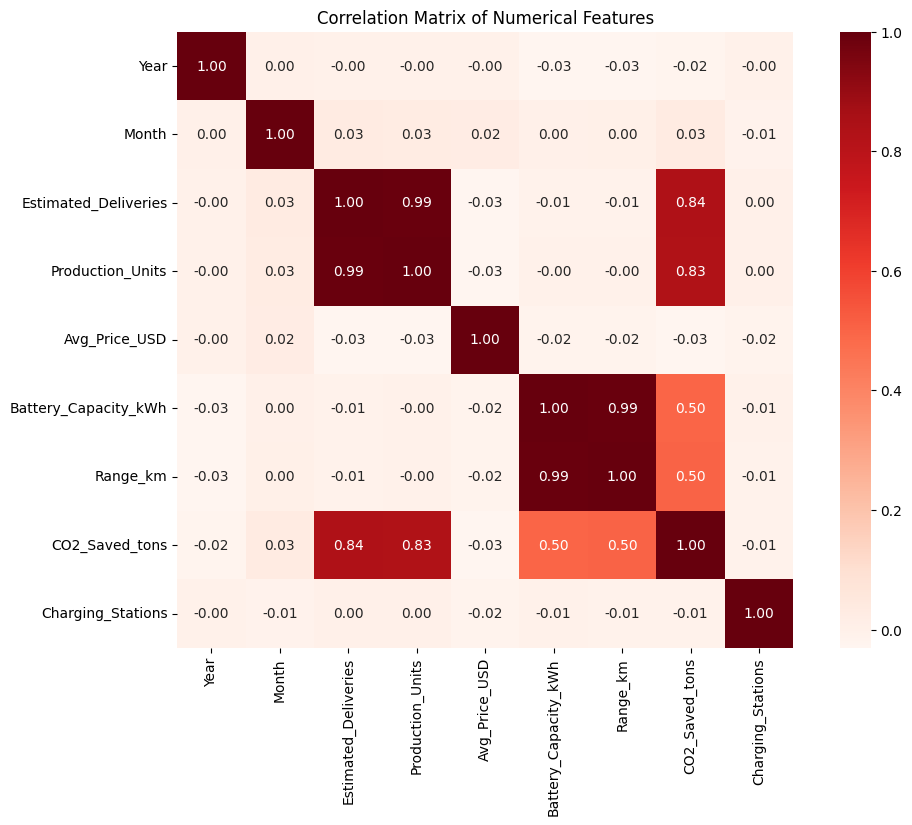

In [9]:
print("Calculating the Correlation Matrix")

# Correlation heatmap for numerical features
numerical_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 8))
sns.heatmap(numerical_df.corr(), annot=True, fmt=".2f", cmap="Reds", square=True)
plt.title("Correlation Matrix of Numerical Features")
plt.show()

Time Series Analysis

Graph for Avg Price Trend vs Years


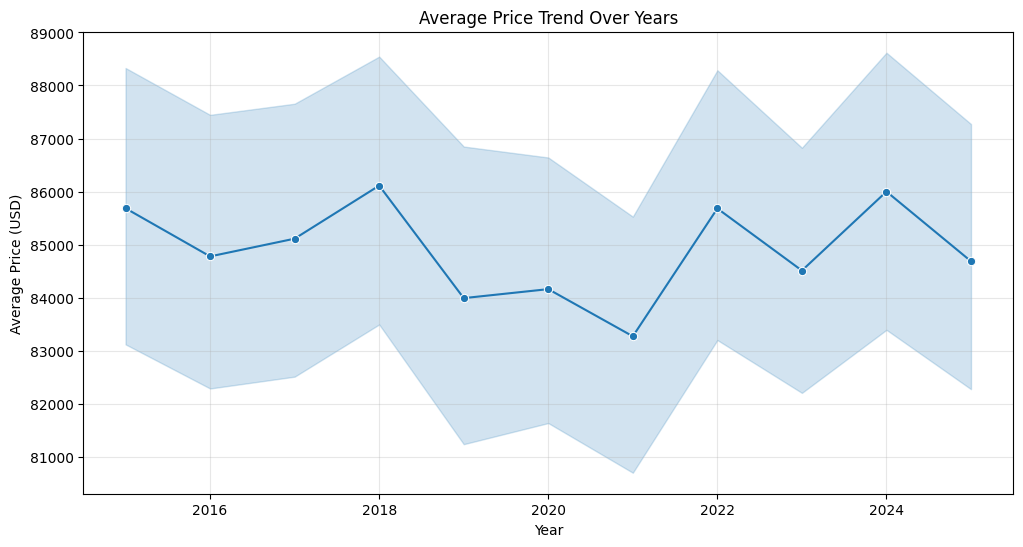

Graph for Avg Price Trend vs Month


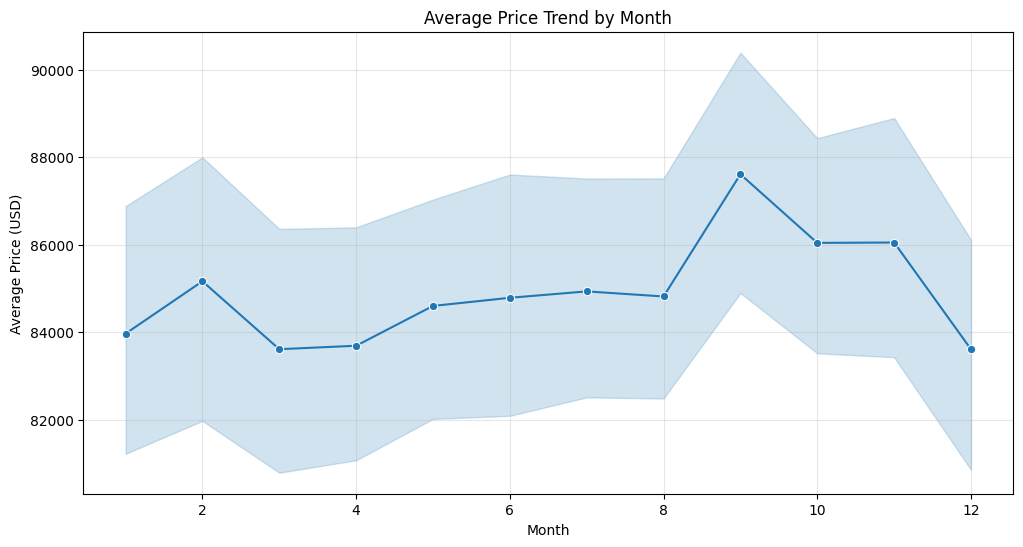

In [10]:
print("Graph for Avg Price Trend vs Years")

# Price trend over years
plt.figure(figsize=(12, 6))
sns.lineplot(x="Year", y="Avg_Price_USD", data=df, marker="o")
plt.title("Average Price Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Average Price (USD)")
plt.grid(True, alpha=0.3)
plt.show()

print("Graph for Avg Price Trend vs Month")

# Price trend by month
plt.figure(figsize=(12, 6))
sns.lineplot(x="Month", y="Avg_Price_USD", data=df, marker="o")
plt.title("Average Price Trend by Month")
plt.xlabel("Month")
plt.ylabel("Average Price (USD)")
plt.grid(True, alpha=0.3)
plt.show()

Production vs Deliveries Analysis

Graph for Production VS Estimated Deliveries


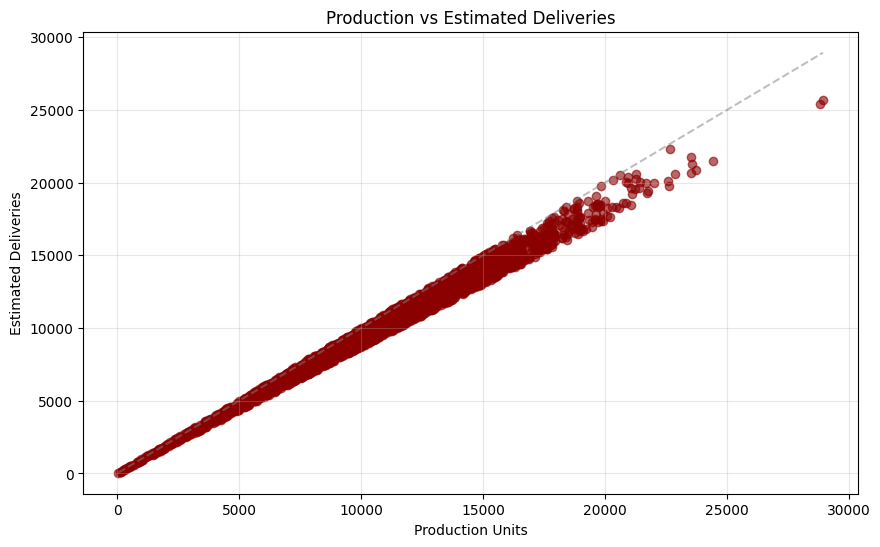

In [11]:
print("Graph for Production VS Estimated Deliveries")

# Scatter plot: Production vs Estimated Deliveries
plt.figure(figsize=(10, 6))
plt.scatter(
    df["Production_Units"], df["Estimated_Deliveries"], alpha=0.6, color="darkred"
)
plt.plot(
    [df["Production_Units"].min(), df["Production_Units"].max()],
    [df["Production_Units"].min(), df["Production_Units"].max()],
    "--",
    color="gray",
    alpha=0.5,
)
plt.xlabel("Production Units")
plt.ylabel("Estimated Deliveries")
plt.title("Production vs Estimated Deliveries")
plt.grid(True, alpha=0.3)
plt.show()

Key Insights Summary

In [12]:
print("Key Insights from EDA:\n")

print(f"7. Average Range: {df['Range_km'].mean():.0f} km")
print(f"4. Most common region: {df['Region'].mode()[0]}")
print(f"5. Most common model: {df['Model'].mode()[0]}")
print(f"3. Average Deliveries: {df['Estimated_Deliveries'].mean():,.0f} units")
print(f"2. Average Production: {df['Production_Units'].mean():,.0f} units")
print(f"6. Average Battery Capacity: {df['Battery_Capacity_kWh'].mean():.0f} kWh")
print(
    f"1. Price Range ($): ${df['Avg_Price_USD'].min():,.0f} - ${df['Avg_Price_USD'].max():,.0f}"
)


Key Insights from EDA:

7. Average Range: 500 km
4. Most common region: Asia
5. Most common model: Cybertruck
3. Average Deliveries: 9,922 units
2. Average Production: 10,656 units
6. Average Battery Capacity: 87 kWh
1. Price Range ($): $50,004 - $119,965


#### Section 3: Feature Engineering

Create Time-Based Features

In [13]:
# Extract additional time features
df["Year_Month"] = df["Year"].astype(str) + "-" + df["Month"].astype(str).str.zfill(2)
df["Quarter"] = pd.cut(
    df["Month"], bins=[0, 3, 6, 9, 12], labels=["Q1", "Q2", "Q3", "Q4"]
)
df["Is_Year_End"] = (df["Month"] == 12).astype(int)
df["Is_Quarter_End"] = df["Month"].isin([3, 6, 9, 12]).astype(int)

# Create useful ratio features
df["Delivery_to_Production_Ratio"] = df["Estimated_Deliveries"] / df["Production_Units"]
df["Price_per_kWh"] = df["Avg_Price_USD"] / df["Battery_Capacity_kWh"]
df["Price_per_km"] = df["Avg_Price_USD"] / df["Range_km"]
df["Stations_per_Production"] = df["Charging_Stations"] / df["Production_Units"]

# Range and charging efficiency features
df["Range_per_kWh"] = df["Range_km"] / df["Battery_Capacity_kWh"]
df["CO2_Saved_per_Production"] = df["CO2_Saved_tons"] / df["Production_Units"]

# Create a composite efficiency score
df["Price_Efficiency_Score"] = (df["Range_km"] / df["Avg_Price_USD"]) * 1000

# Create year-over-year features
df["Price_Change"] = df.groupby(["Region", "Model"])["Avg_Price_USD"].pct_change()
df["Production_Change"] = df.groupby(["Region", "Model"])[
    "Production_Units"
].pct_change()

# Fill NaN values (first entry for each group)
df["Price_Change"] = df["Price_Change"].fillna(0)
df["Production_Change"] = df["Production_Change"].fillna(0)

#### Section 4: Data Preprocessing

Identify Feature Types

In [14]:
# Separate features into different types
numeric_features = [
    "Year",
    "Month",
    "Estimated_Deliveries",
    "Avg_Price_USD",
    "Battery_Capacity_kWh",
    "Range_km",
    "CO2_Saved_tons",
    "Charging_Stations",
    "Delivery_to_Production_Ratio",
    "Price_per_kWh",
    "Price_per_km",
    "Stations_per_Production",
    "Range_per_kWh",
    "CO2_Saved_per_Production",
    "Price_Efficiency_Score",
    "Price_Change",
    "Production_Change",
]

categorical_features = ["Region", "Model", "Source_Type", "Quarter"]

# Features to exclude from modeling
exclude_features = ["Year_Month", "Is_Year_End", "Is_Quarter_End"]

Prepare Feature Matrix

In [15]:
# Select features for modeling
feature_columns = numeric_features + categorical_features
X = df[feature_columns]
y = df["Production_Units"]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (2640, 21)
Target shape: (2640,)


Model training-Train-Test Split

In [16]:
from sklearn.model_selection import train_test_split

# Split data with stratification based on production quartiles
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 2112
Test set size: 528


#### Section 5: Pipeline Setup for Modeling

Preprocessing Pipeline

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Preprocessing for numerical features
numeric_transformer = Pipeline(steps=[("scaler", StandardScaler())])

# Preprocessing for categorical features
categorical_transformer = Pipeline(
    steps=[("onehot", OneHotEncoder(handle_unknown="ignore"))]
)

# Combine preprocessors
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

Helper Function for Model Evaluation

In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np


def evaluate_model(model, X_test, y_test):
    """
    Evaluate regression model performance
    """
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"RMSE: {rmse:,.0f}")
    print(f"MAE: {mae:,.0f}")
    print(f"R² Score: {r2:.4f}")

    return {"RMSE": rmse, "MAE": mae, "R2": r2}

#### Section 6: Regression Modeling

Linear Regression (Baseline)

In [19]:
from sklearn.linear_model import LinearRegression

# Create pipeline
lr_pipeline = Pipeline(
    steps=[("preprocessor", preprocessor), ("regressor", LinearRegression())]
)

# Train the model
lr_pipeline.fit(X_train, y_train)

# Evaluate
print("Linear Regression Performance:\n")
lr_scores = evaluate_model(lr_pipeline, X_test, y_test)

Linear Regression Performance:

RMSE: 167
MAE: 118
R² Score: 0.9984


Ridge Regression (L2 Regularization)

In [20]:
from sklearn.linear_model import Ridge

# Create pipeline with Ridge
ridge_pipeline = Pipeline(
    steps=[("preprocessor", preprocessor), ("regressor", Ridge(alpha=1.0))]
)

# Train the model
ridge_pipeline.fit(X_train, y_train)

# Evaluate
print("Ridge Regression Performance:\n")
ridge_scores = evaluate_model(ridge_pipeline, X_test, y_test)

Ridge Regression Performance:

RMSE: 166
MAE: 118
R² Score: 0.9984


Lasso Regression (L1 Regularization)

In [21]:
from sklearn.linear_model import Lasso

# Create pipeline with Lasso
lasso_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", Lasso(alpha=1.0, max_iter=10000)),
    ]
)

# Train the model
lasso_pipeline.fit(X_train, y_train)

# Evaluate
print("Lasso Regression Performance:\n")
lasso_scores = evaluate_model(lasso_pipeline, X_test, y_test)

Lasso Regression Performance:

RMSE: 166
MAE: 117
R² Score: 0.9984


Random Forest Regression

In [22]:
from sklearn.ensemble import RandomForestRegressor

# Create pipeline with Random Forest
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "regressor",
            RandomForestRegressor(
                n_estimators=100,
                max_depth=15,
                min_samples_split=5,
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

# Train the model
rf_pipeline.fit(X_train, y_train)

# Evaluate
print("Random Forest Performance:\n")
rf_scores = evaluate_model(rf_pipeline, X_test, y_test)

Random Forest Performance:

RMSE: 122
MAE: 78
R² Score: 0.9991


Gradient Boosting Regression

In [23]:
from sklearn.ensemble import GradientBoostingRegressor

# Create pipeline with Gradient Boosting
gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "regressor",
            GradientBoostingRegressor(
                n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42
            ),
        ),
    ]
)

# Train the model
gb_pipeline.fit(X_train, y_train)

# Evaluate
print("Gradient Boosting Performance:\n")
gb_scores = evaluate_model(gb_pipeline, X_test, y_test)

Gradient Boosting Performance:

RMSE: 83
MAE: 59
R² Score: 0.9996


Model Comparison Summary

In [24]:
# Collect all scores
models = ["Linear Regression", "Ridge", "Lasso", "Random Forest", "Gradient Boosting"]
scores = [lr_scores, ridge_scores, lasso_scores, rf_scores, gb_scores]

# Create comparison dataframe
comparison_df = pd.DataFrame(scores, index=models)
print("\nModel Performance Comparison:\n")
print(comparison_df.round(4))

# Identify best model
best_model = comparison_df["R2"].idxmax()
print(f"\nBest Model: {best_model} with R² = {comparison_df.loc[best_model, 'R2']:.4f}")


Model Performance Comparison:

                       RMSE       MAE      R2
Linear Regression  166.7288  117.7860  0.9984
Ridge              166.4082  117.5411  0.9984
Lasso              165.7318  117.3390  0.9984
Random Forest      122.1728   78.0321  0.9991
Gradient Boosting   82.7545   58.7854  0.9996

Best Model: Gradient Boosting with R² = 0.9996


Feature Importance (Top Models)

Top 15 Most Important Features (Random Forest):

                                Feature  Importance
2             num__Estimated_Deliveries    0.990168
8     num__Delivery_to_Production_Ratio    0.008607
6                   num__CO2_Saved_tons    0.000165
11         num__Stations_per_Production    0.000150
16               num__Production_Change    0.000120
12                   num__Range_per_kWh    0.000104
3                    num__Avg_Price_USD    0.000076
7                num__Charging_Stations    0.000076
15                    num__Price_Change    0.000073
28  cat__Source_Type_Official (Quarter)    0.000059
13        num__CO2_Saved_per_Production    0.000056
1                            num__Month    0.000055
9                    num__Price_per_kWh    0.000051
5                         num__Range_km    0.000043
14          num__Price_Efficiency_Score    0.000039

Graphical Visualization of Important features


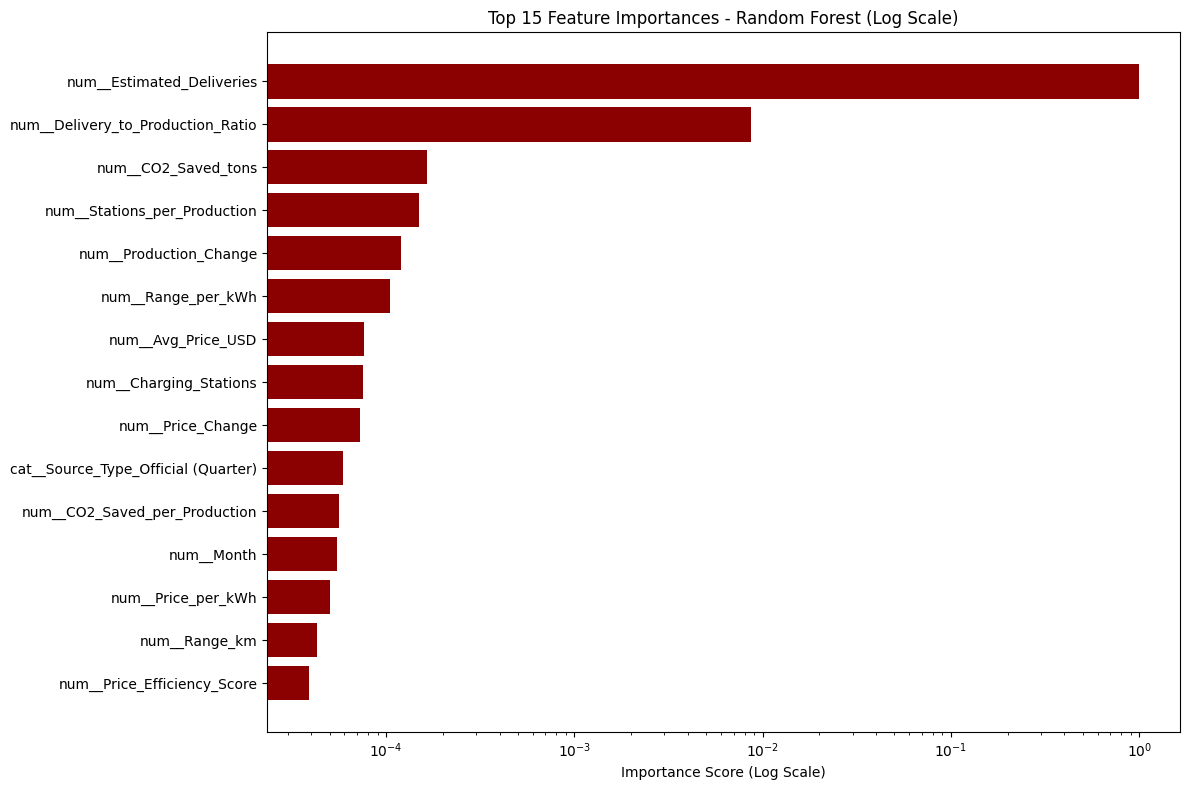

In [25]:
# Get feature names after preprocessing
# For Random Forest
rf_model = rf_pipeline.named_steps["regressor"]
feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()

# Get feature importances
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame(
    {"Feature": feature_names, "Importance": importances}
).sort_values("Importance", ascending=False)

# Display top 15 features
print("Top 15 Most Important Features (Random Forest):\n")
print(feature_importance_df.head(15))

print("\nGraphical Visualization of Important features")

# Visualize feature importance with logarithmic scale
plt.figure(figsize=(12, 8))
top_features = feature_importance_df.head(15)
bars = plt.barh(top_features["Feature"], top_features["Importance"], color="darkred")

# Use logarithmic scale to better visualize small values
plt.xscale('log')
plt.xlabel("Importance Score (Log Scale)")
plt.title("Top 15 Feature Importances - Random Forest (Log Scale)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#### Section 7: Hyperparameter Tuning

Cross-Validation Setup

In [26]:
from sklearn.model_selection import cross_val_score, KFold

# Setup cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def cv_evaluate(model, X, y, cv=kf):
    """
    Evaluate model using cross-validation
    """
    scores = cross_val_score(model, X, y, cv=cv, scoring="r2")
    print(f"Cross-validation R² Scores: {scores}")
    print(f"Mean R²: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")
    return scores

Ridge Hyperparameter Tuning

In [27]:
from sklearn.model_selection import GridSearchCV

# Ridge parameter grid
ridge_param_grid = {"regressor__alpha": [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]}

# Grid search for Ridge
ridge_grid = GridSearchCV(
    ridge_pipeline, param_grid=ridge_param_grid, cv=5, scoring="r2", n_jobs=-1
)

# Fit grid search
ridge_grid.fit(X_train, y_train)

print("Ridge Best Parameters:",ridge_grid.best_params_)
print(f"Best R² Score: {ridge_grid.best_score_:.4f}")

Ridge Best Parameters: {'regressor__alpha': 0.1}
Best R² Score: 0.9984


Random Forest Hyperparameter Tuning

In [28]:
# Random Forest parameter grid
rf_param_grid = {
    "regressor__n_estimators": [50, 100, 200],
    "regressor__max_depth": [10, 15, 20, None],
    "regressor__min_samples_split": [2, 5, 10],
}

# Grid search for Random Forest
rf_grid = GridSearchCV(
    rf_pipeline,
    param_grid=rf_param_grid,
    cv=3,  # 3-fold CV for speed
    scoring="r2",
    n_jobs=-1,
    verbose=1,
)

# Fit grid search
rf_grid.fit(X_train, y_train)

print("\nRandom Forest Best Parameters:",rf_grid.best_params_)
print(f"Best R² Score: {rf_grid.best_score_:.4f}")

Fitting 3 folds for each of 36 candidates, totalling 108 fits

Random Forest Best Parameters: {'regressor__max_depth': 20, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 200}
Best R² Score: 0.9974


Gradient Boosting Hyperparameter Tuning

In [29]:
# Gradient Boosting parameter grid
gb_param_grid = {
    "regressor__n_estimators": [50, 100, 200],
    "regressor__learning_rate": [0.01, 0.05, 0.1],
    "regressor__max_depth": [3, 5, 7],
    "regressor__subsample": [0.8, 0.9, 1.0],
}

# Grid search for Gradient Boosting
gb_grid = GridSearchCV(
    gb_pipeline, param_grid=gb_param_grid, cv=3, scoring="r2", n_jobs=-1, verbose=1
)

# Fit grid search
gb_grid.fit(X_train, y_train)

print("\nGradient Boosting Best Parameters:",gb_grid.best_params_)
print(f"Best R² Score: {gb_grid.best_score_:.4f}")

Fitting 3 folds for each of 81 candidates, totalling 243 fits

Gradient Boosting Best Parameters: {'regressor__learning_rate': 0.1, 'regressor__max_depth': 3, 'regressor__n_estimators': 200, 'regressor__subsample': 0.9}
Best R² Score: 0.9989


Compare Best Models After Tuning

In [30]:
# Test best models on test set
print("Final Model Performance on Test Set:")

# Ridge tuned model
ridge_tuned = ridge_grid.best_estimator_
print("\nTuned Ridge:")
ridge_tuned_scores = evaluate_model(ridge_tuned, X_test, y_test)

# Random Forest tuned model
rf_tuned = rf_grid.best_estimator_
print("\nTuned Random Forest:")
rf_tuned_scores = evaluate_model(rf_tuned, X_test, y_test)

# Gradient Boosting tuned model
gb_tuned = gb_grid.best_estimator_
print("\nTuned Gradient Boosting:")
gb_tuned_scores = evaluate_model(gb_tuned, X_test, y_test)

Final Model Performance on Test Set:

Tuned Ridge:
RMSE: 167
MAE: 118
R² Score: 0.9984

Tuned Random Forest:
RMSE: 119
MAE: 76
R² Score: 0.9992

Tuned Gradient Boosting:
RMSE: 89
MAE: 70
R² Score: 0.9995


#### Section 8: Time Series Forecasting

Prepare Time Series Data

In [31]:
# Create time series data for forecasting
df_ts = df.copy()
df_ts["Date"] = pd.to_datetime(
    df_ts["Year"].astype(str) + "-" + df_ts["Month"].astype(str).str.zfill(2) + "-01"
)
df_ts = df_ts.sort_values(["Region", "Model", "Date"])

# Create lag features
def create_lag_features(df, group_cols, target_col, lags=[1, 2, 3, 6, 12]):
    """
    Create lag features for time series forecasting
    """
    for lag in lags:
        df[f"{target_col}_lag_{lag}"] = df.groupby(group_cols)[target_col].shift(lag)
    return df

# Create lag features for production
df_ts = create_lag_features(
    df_ts, ["Region", "Model"], "Production_Units", lags=[1, 2, 3, 6, 12]
)

# Add rolling statistics
df_ts["Production_Units_rolling_3"] = df_ts.groupby(["Region", "Model"])[
    "Production_Units"
].transform(lambda x: x.rolling(3, min_periods=1).mean())
df_ts["Production_Units_rolling_6"] = df_ts.groupby(["Region", "Model"])[
    "Production_Units"
].transform(lambda x: x.rolling(6, min_periods=1).mean())

# Drop rows with NaN values created by lags/rolling
df_ts = df_ts.dropna()

Train-Test Split for Time Series

In [32]:
# Split by time (last 20% for testing)
split_idx = int(len(df_ts) * 0.8)
ts_features = [
    "Year",
    "Month",
    "Estimated_Deliveries",
    "Avg_Price_USD",
    "Battery_Capacity_kWh",
    "Range_km",
    "CO2_Saved_tons",
    "Charging_Stations",
    "Production_Units_lag_1",
    "Production_Units_lag_2",
    "Production_Units_lag_3",
    "Production_Units_lag_6",
    "Production_Units_lag_12",
    "Production_Units_rolling_3",
    "Production_Units_rolling_6",
]

X_ts = df_ts[ts_features]
y_ts = df_ts["Production_Units"]

X_ts_train = X_ts[:split_idx]
X_ts_test = X_ts[split_idx:]
y_ts_train = y_ts[:split_idx]
y_ts_test = y_ts[split_idx:]

print(f"Time Series Training set: {X_ts_train.shape[0]} samples")
print(f"Time Series Test set: {X_ts_test.shape[0]} samples")

Time Series Training set: 1920 samples
Time Series Test set: 480 samples


Time Series Model with Lag Features

In [33]:
from sklearn.ensemble import RandomForestRegressor

# Create pipeline for time series
ts_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "regressor",
            RandomForestRegressor(
                n_estimators=200,
                max_depth=15,
                min_samples_split=5,
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

# Train the model
ts_pipeline.fit(X_ts_train, y_ts_train)

# Evaluate
print("Time Series Model Performance:\n")
y_ts_pred = ts_pipeline.predict(X_ts_test)

mse_ts = mean_squared_error(y_ts_test, y_ts_pred)
rmse_ts = np.sqrt(mse_ts)
mae_ts = mean_absolute_error(y_ts_test, y_ts_pred)
r2_ts = r2_score(y_ts_test, y_ts_pred)

print(f"RMSE: {rmse_ts:,.0f}")
print(f"MAE: {mae_ts:,.0f}")
print(f"R² Score: {r2_ts:.4f}")

Time Series Model Performance:

RMSE: 536
MAE: 390
R² Score: 0.9840


Time Series Feature Importance

In [34]:
# Get feature importances
ts_importance = pd.DataFrame(
    {
        "Feature": ts_features,
        "Importance": ts_pipeline.named_steps["regressor"].feature_importances_,
    }
).sort_values("Importance", ascending=False)

print("Top 10 Time Series Features:\n")
print(ts_importance.head(10))

Top 10 Time Series Features:

                       Feature  Importance
2         Estimated_Deliveries    0.990966
3                Avg_Price_USD    0.000999
11      Production_Units_lag_6    0.000816
10      Production_Units_lag_3    0.000812
7            Charging_Stations    0.000779
14  Production_Units_rolling_6    0.000749
9       Production_Units_lag_2    0.000732
13  Production_Units_rolling_3    0.000710
12     Production_Units_lag_12    0.000706
8       Production_Units_lag_1    0.000683


Predict Next Period Production

In [35]:
# Function to predict next period production
def predict_next_production(model, recent_data):
    """
    Predict production for the next time period
    """
    # Prepare features for next period
    next_features = recent_data.iloc[-1:].copy()

    # Update for next month/year
    next_features["Month"] = next_features["Month"] + 1
    # Handle year rollover
    next_features.loc[next_features["Month"] > 12, "Month"] = 1
    next_features.loc[next_features["Month"] == 1, "Year"] = next_features["Year"] + 1

    # Make prediction
    prediction = model.predict(next_features[ts_features])
    return prediction[0]


# Example: Predict next month's production for first region-model combination
example_data = df_ts[df_ts["Region"] == df_ts["Region"].iloc[0]]
if len(example_data) > 0:
    next_prod = predict_next_production(ts_pipeline, example_data)
    print(f"Predicted next month production: {next_prod:,.0f} units")

Predicted next month production: 16,092 units


#### Section 9: Model Persistence and Final Summary

Save the Best Model

In [36]:
import joblib

# Save the best performing model (example: tuned Random Forest)
best_model = rf_grid.best_estimator_
joblib.dump(best_model, "Models/Best_Production_Model.pkl")

print("Best model saved as 'Best_Production_Model.pkl'")

Best model saved as 'Best_Production_Model.pkl'


Final Model Performance Summary

In [37]:
print("FINAL MODEL PERFORMANCE SUMMARY")

print("\n1. REGRESSION MODELS (Cross-validation):")
print(f"   Best Model: {best_model}")
print(f"   Best CV R² Score: {rf_grid.best_score_:.4f}")

print("\n2. TIME SERIES MODEL:")
print(f"   R² Score: {r2_ts:.4f}")
print(f"   RMSE: {rmse_ts:,.0f} units")

print("\n3. KEY INSIGHTS:")
print(f"   • Production can be predicted with {r2_ts*100:.1f}% accuracy using time series features")
print(f"   • Most important features: {' > '.join(ts_importance.head(3)['Feature'].values)}")
print(f"   • Linear Regression baseline R²: {lr_scores['R2']:.4f}")
print(f"   • Tuned Random Forest R²: {rf_tuned_scores['R2']:.4f}")

FINAL MODEL PERFORMANCE SUMMARY

1. REGRESSION MODELS (Cross-validation):
   Best Model: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Year', 'Month',
                                                   'Estimated_Deliveries',
                                                   'Avg_Price_USD',
                                                   'Battery_Capacity_kWh',
                                                   'Range_km', 'CO2_Saved_tons',
                                                   'Charging_Stations',
                                                   'Delivery_to_Production_Ratio',
                                                   'Price_per_kWh',
                                                   'Price_per_km',

Pipeline Visualization

In [38]:
# Visualize the complete pipeline
from sklearn import set_config

set_config(display="diagram")

# Display the pipeline structure
print("Complete Modeling Pipeline Structure:")
print(rf_grid.best_estimator_)

Complete Modeling Pipeline Structure:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Year', 'Month',
                                                   'Estimated_Deliveries',
                                                   'Avg_Price_USD',
                                                   'Battery_Capacity_kWh',
                                                   'Range_km', 'CO2_Saved_tons',
                                                   'Charging_Stations',
                                                   'Delivery_to_Production_Ratio',
                                                   'Price_per_kWh',
                                                   'Price_per_km',
                                                  

#### Section 10: Additional Visualizations for Reporting

Prediction vs Actual Plot

Graphical Visualization for Prediction VS Actual Plot


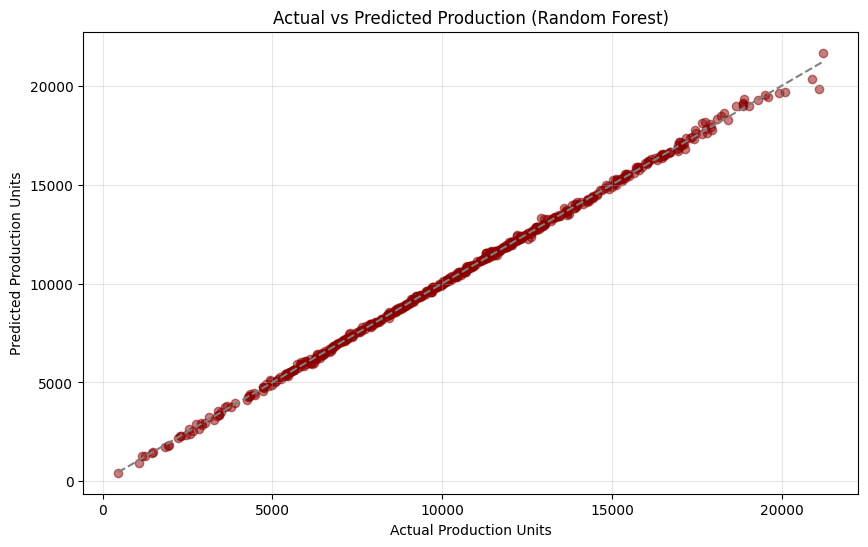

In [39]:
print("Graphical Visualization for Prediction VS Actual Plot")

# Plot actual vs predicted for the best model
plt.figure(figsize=(10, 6))
y_pred_best = rf_grid.best_estimator_.predict(X_test)
plt.scatter(y_test, y_pred_best, alpha=0.5, color="darkred")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "--", color="gray")
plt.xlabel("Actual Production Units")
plt.ylabel("Predicted Production Units")
plt.title("Actual vs Predicted Production (Random Forest)")
plt.grid(True, alpha=0.3)
plt.show()

Residual Analysis

Graph for residual data analysis


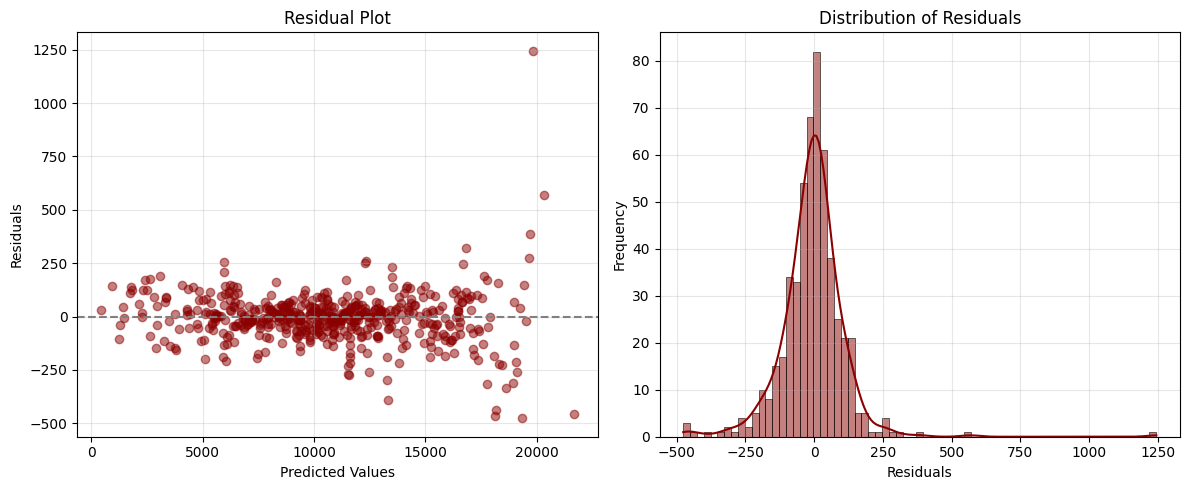

Residual Statistics:

Mean: -6
Std Dev: 119


In [40]:
print("Graph for residual data analysis")

# Calculate residuals
residuals = y_test - y_pred_best

# Plot residuals
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_pred_best, residuals, alpha=0.5, color="darkred")
plt.axhline(y=0, color="gray", linestyle="--")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, color="darkred")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Residual Statistics:\n")
print(f"Mean: {np.mean(residuals):.0f}")
print(f"Std Dev: {np.std(residuals):.0f}")

---
## 🏁 Submission Checklist

- ✅ Markdown are used with proper description. 
- ✅ All plots render with labels and titles.
- ✅ Notebook runs cleanly from top to bottom (`Kernel → Restart & Run All`)

**Saved as:** `week2_Amulya_Shrivastava.ipynb`